<a href="https://colab.research.google.com/github/JosephBless/Deep-Learning-Colab/blob/main/Chap_13%EF%BC%9A%E7%84%A1%E7%9B%A3%E7%9D%A3%E5%AD%B8%E7%BF%92_%26_%E6%A8%A1%E5%9E%8B%E5%84%AA%E5%8C%96%E8%88%87%E4%BA%A4%E5%8F%89%E9%A9%97%E8%AD%89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Colab 進行matplotlib繪圖時顯示繁體中文
# 下載台北思源黑體並命名taipei_sans_tc_beta.ttf，移至指定路徑
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

import matplotlib

# 改style要在改font之前
# plt.style.use('seaborn')

matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')

--2024-09-27 18:45:46--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 172.217.214.100, 172.217.214.102, 172.217.214.113, ...
Connecting to drive.google.com (drive.google.com)|172.217.214.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2024-09-27 18:45:46--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.184.132, 2607:f8b0:4001:c66::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.184.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================>]  19.70M  43.6MB/s    in 0.5s    

2024-09-27 

在上節中，我們介紹了監督學習在股市裡的應用，在本節中，我們將結合無監督學習和模型優化技術。首先，我們將探討如何應用聚類算法（如K-Means）來識別市場模式，以及如何使用主成分分析（PCA）進行數據降維。接著，我們將深入了解模型優化的方法，包括超參數調整和交叉驗證，以防止過擬合並提高模型的泛化能力。

### **一、無監督學習概述**

#### **1. 什麼是無監督學習**

無監督學習是一種機器學習方法，利用未標記的數據來發現數據中的內在結構或模式。與監督式學習不同，無監督學習不需要目標變量（標籤），主要應用於：

- **聚類**：將相似的數據點分組。
- **降維**：降低數據的維度，同時保留主要信息。
- **異常檢測**：識別數據中的異常或偏差。

#### **2. 金融領域的應用**

- **市場細分**：將股票或客戶分成不同的群組。
- **模式識別**：發現市場的隱藏模式或趨勢。
- **風險管理**：識別異常交易或風險事件。

---

### **二、應用K-Means聚類識別市場模式**

#### **1. K-Means聚類算法**

##### **(1) 概念**

K-Means是一種常用的聚類算法，目的是將數據分成 $ K $ 個聚類，使得同一聚類內的數據點彼此盡可能接近，而不同聚類之間的數據點盡可能遠離。

##### **(2) 算法步驟**

1. **選擇K值**：確定聚類的數量 $ K $。
2. **初始化質心**：隨機選擇 $ K $ 個初始質心。
3. **分配數據點**：將每個數據點分配到最近的質心所在的聚類。
4. **更新質心**：計算每個聚類的平均值，作為新的質心。
5. **重複步驟3和4**，直到質心不再改變或達到最大迭代次數。

#### **2. 在金融數據中的應用**

##### **(1) 目標**

- 將股票按特徵（如收益率、波動率、市值等）分組，識別市場中的不同類型的股票。
- 發現市場中的隱藏模式，輔助投資決策。

##### **(2) Python實現**

[*********************100%***********************]  10 of 10 completed


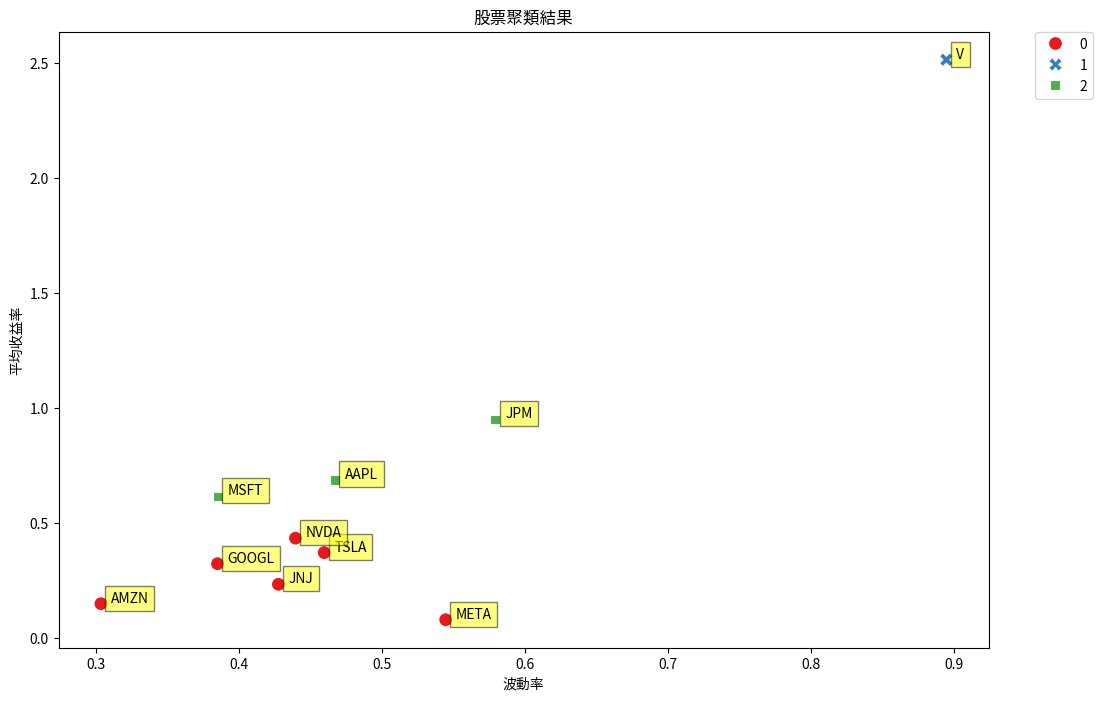

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 獲取多支股票的數據
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'NVDA', 'JPM', 'V', 'JNJ']
data = yf.download(tickers, start='2020-01-01', end='2021-01-01')['Adj Close']

# 計算每日收益率
returns = data.pct_change().dropna()

# 計算平均收益率和波動率
mean_returns = returns.mean() * 252
volatility = returns.std() * np.sqrt(252)

# 構建特徵數據集，添加股票代碼
features = pd.DataFrame({'Ticker': tickers, 'Mean Returns': mean_returns.values, 'Volatility': volatility.values})

# K-Means 聚類
k = 3  # 假設分為 3 個聚類
kmeans = KMeans(n_clusters=k, random_state=0)
kmeans.fit(features[['Mean Returns', 'Volatility']])
labels = kmeans.labels_

# 添加聚類標籤
features['Cluster'] = labels

# 可視化聚類結果並標註股票代碼
plt.figure(figsize=(12,8))
scatter = sns.scatterplot(x='Volatility', y='Mean Returns', data=features, hue='Cluster', style='Cluster', s=100, palette='Set1')

# 調整圖例位置
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# 添加股票代碼標籤
for i in range(features.shape[0]):
    plt.text(x=features['Volatility'][i]+0.007, y=features['Mean Returns'][i]+0.007,
             s=features['Ticker'][i],
             fontdict=dict(color='black', size=10),
             bbox=dict(facecolor='yellow', alpha=0.5, edgecolor='black'))

plt.title('股票聚類結果')
plt.xlabel('波動率')
plt.ylabel('平均收益率')
plt.show()


**解釋：**

- **數據準備**：獲取多支股票的歷史價格，計算其平均收益率和波動率作為特徵。
- **聚類**：使用K-Means算法將股票分為 ` K ` 個聚類。
- **可視化**：繪製散點圖，觀察不同聚類的分佈情況。

##### **(3) 選擇最佳K值**

- **手肘法（Elbow Method）**：通過繪製 **SSE（Sum of Squared Errors）**隨 ` K ` 值變化的圖，選擇拐點處的 ` K ` 值。

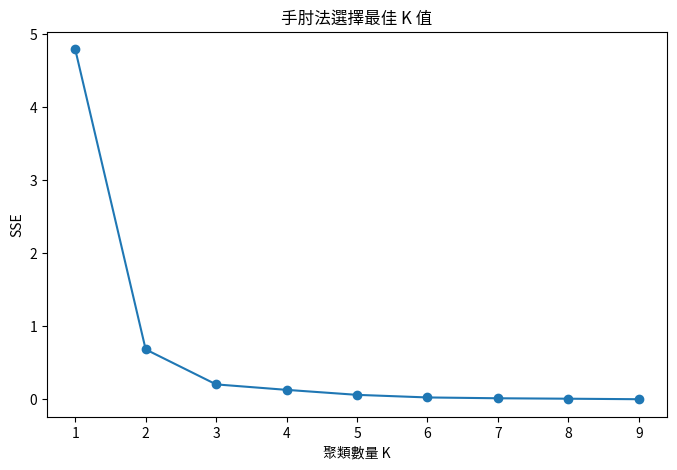

In [ ]:
sse = []
k_range = range(1, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(features[['Mean Returns', 'Volatility']])
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, sse, marker='o')
plt.xlabel('聚類數量 K')
plt.ylabel('SSE')
plt.title('手肘法選擇最佳 K 值')
plt.show()

### **三、主成分分析（PCA）進行數據降維**

#### **1. PCA概念**

主成分分析（PCA）是一種降維技術，通過將高維數據投影到較低維的空間，提取數據中最重要的變異方向，同時保留主要信息。

#### **2. 在金融數據中的應用**

- **降低特徵維度**：處理高維度的金融數據，如宏觀經濟指標、技術指標等。
- **消除特徵相關性**：PCA生成的主成分是相互正交的，減少了特徵間的相關性。

#### **3. Python實現**

##### **(1) 數據準備**

- 獲取多支股票的收益率，構建高維度的特徵矩陣。

In [ ]:
# 使用前面獲取的 returns 數據
X = returns

# 標準化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

##### **(2) 應用PCA**

In [ ]:
from sklearn.decomposition import PCA

# 設置要保留的主成分數量
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# 解釋方差比例
explained_variance = pca.explained_variance_ratio_
print('解釋方差比例：', explained_variance)

# 將主成分轉換為DataFrame
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

解釋方差比例： [0.66080127 0.10549888]


##### **(3) 可視化結果**

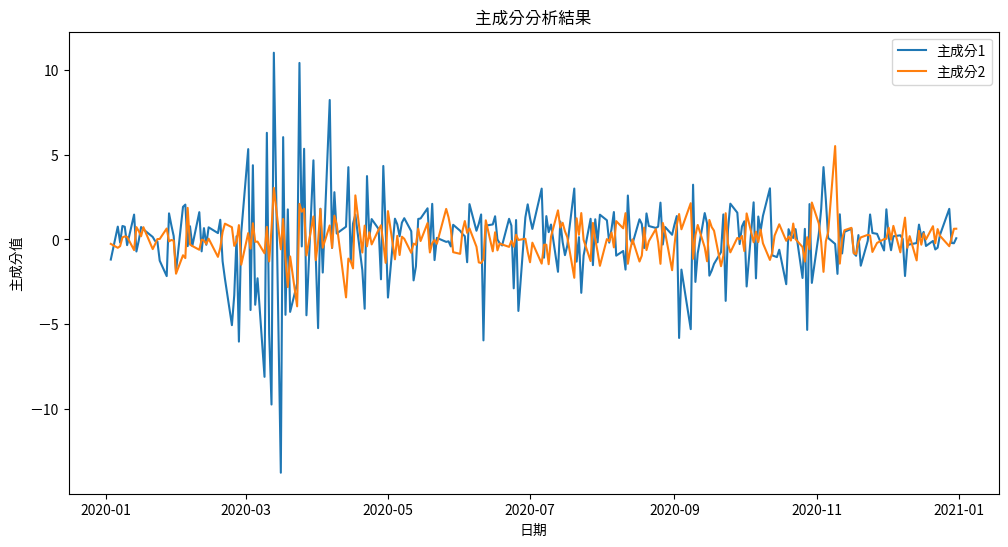

In [ ]:
# 將日期加入DataFrame
pca_df['Date'] = returns.index
pca_df.set_index('Date', inplace=True)

# 繪製主成分隨時間的走勢
plt.figure(figsize=(12,6))
plt.plot(pca_df.index, pca_df['PC1'], label='主成分1')
plt.plot(pca_df.index, pca_df['PC2'], label='主成分2')
plt.title('主成分分析結果')
plt.xlabel('日期')
plt.ylabel('主成分值')
plt.legend()
plt.show()

### **四、模型優化與交叉驗證**

#### **1. 為什麼需要模型優化**

- **提高模型性能**：尋找最佳的模型參數組合，提升預測能力。
- **防止過擬合**：避免模型過度擬合訓練數據，導致泛化能力差。

#### **2. 超參數調整**

##### **(1) 概念**

- **超參數**：模型中需要預先設定的參數，如決策樹的深度、KNN的鄰居數等。
- **調整方法**：通過測試不同的超參數組合，選擇使模型性能最優的組合。

##### **(2) 網格搜索（Grid Search）**

- **使用方法**：設定參數網格，遍歷所有可能的參數組合，評估模型性能。
- **實現**


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# 1. 獲取股票數據
data = yf.download('AAPL', start='2015-01-01', end='2021-01-01')

# 2. 特徵工程
data['Returns'] = data['Adj Close'].pct_change()
data['SMA'] = data['Adj Close'].rolling(window=20).mean()
data['Volatility'] = data['Returns'].rolling(window=20).std()

# 安裝並導入 ta 庫以計算 RSI
!pip install ta
import ta

# 計算 RSI
data['RSI'] = ta.momentum.RSIIndicator(close=data['Adj Close'], window=14).rsi()

# 移除缺失值
data.dropna(inplace=True)

# 3. 構建特徵和標籤
# 標籤：未來一天的價格漲跌
data['Target'] = np.where(data['Returns'].shift(-1) > 0, 1, 0)
data.dropna(inplace=True)

features = ['SMA', 'Volatility', 'RSI']
X = data[features]
y = data['Target']

# 4. 分割訓練集和測試集
# 保持時間序列順序，防止未來數據洩漏
split_date = '2020-01-01'
X_train = X[X.index < split_date]
X_test = X[X.index >= split_date]
y_train = y[y.index < split_date]
y_test = y[y.index >= split_date]

# 5. 標準化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. 定義參數網格
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'linear']
}

# 7. 建立模型
model = SVC()

# 8. 使用 TimeSeriesSplit 進行時間序列交叉驗證
tscv = TimeSeriesSplit(n_splits=5)

# 使用 GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=tscv, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

# 9. 最佳參數和模型
print('最佳參數：', grid_search.best_params_)
print('最佳交叉驗證得分：', grid_search.best_score_)

# 10. 使用最佳模型進行預測
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

# 11. 評估模型
accuracy = accuracy_score(y_test, y_pred)
print(f'測試集準確率：{accuracy:.2%}')
print('分類報告：\n', classification_report(y_test, y_pred))


[*********************100%***********************]  1 of 1 completed


  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=ea7f2fce8670a8f2298eb5049b5369706b9fc3bbf50971b73c4424f7bf945855
  Stored in directory: /root/.cache/pip/wheels/5f/67/4f/8a9f252836e053e532c6587a3230bc72a4deb16b03a829610b
Successfully built ta
最佳參數： {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
最佳交叉驗證得分： 0.5184466019417476
測試集準確率：53.75%
分類報告：
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       117
           1       0.54      1.00      0.70       136

    accuracy                           0.54       253
   macro avg       0.27      0.50      0.35       253
weighted avg       0.29      0.54      0.38       253



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### **3. 交叉驗證**

##### **(1) 概念**

交叉驗證是一種評估模型性能的技術，通過將數據集劃分為多個子集，反覆訓練和測試模型，以獲得更穩定的評估結果。

##### **(2) K折交叉驗證**

- **步驟**：
  1. 將數據集劃分為 ` K ` 個子集。
  2. 依次將每個子集作為測試集，剩餘的子集作為訓練集。
  3. 計算每次訓練的模型性能，最終取平均值。

- **實現**

In [ ]:
from sklearn.model_selection import cross_val_score

# 使用5折交叉驗證
scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print('交叉驗證得分：', scores)
print('平均得分：', scores.mean())

交叉驗證得分： [0.43145161 0.41935484 0.43145161 0.47773279 0.50607287]
平均得分： 0.4532127465064647


#### **4. 防止過擬合**

##### **(1) 正則化**

- **概念**：在損失函數中加入懲罰項，限制模型的複雜度。
- **L1正則化（Lasso）** 和 **L2正則化（Ridge）**

In [ ]:
from sklearn.linear_model import Ridge

# 使用Ridge回歸
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_scaled, y_train)

Ridge()

##### **(2) 剪枝（針對決策樹）**

- **概念**：限制決策樹的深度，減少節點數量。
- **實現**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# 限制樹的最大深度
model_tree = DecisionTreeClassifier(max_depth=5)
model_tree.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=5)

##### **(3) 增加數據量**

- **方法**：收集更多的數據，或者使用數據增強技術。

---

### **五、綜合應用：模型優化與無監督學習結合**

#### **1. 先進行特徵降維**

- 使用PCA降低特徵維度，減少模型的計算量和過擬合風險。

#### **2. 構建分類模型**

- 使用降維後的特徵訓練分類模型，如SVM、邏輯回歸等。

#### **3. 模型優化**

- 通過網格搜索和交叉驗證調整模型的超參數，選擇最佳模型。

---

### **六、總結**

在本節中，我們：

- **學習了無監督學習的方法**，如K-Means聚類和PCA，並應用於金融數據分析。
- **掌握了模型優化的技術**，包括超參數調整和交叉驗證，防止過擬合，提高模型泛化能力。
- **將無監督學習與模型優化結合**，實現了更高效的模型構建流程。

*在接下來的學習中，我們將進一步探討時間序列預測和深度學習等進階主題，提升模型的預測能力。*

---

**作業：**

1. **聚類分析**：使用K-Means對更多的股票數據進行聚類，嘗試不同的特徵組合和 $ K $ 值。
2. **降維應用**：使用PCA處理高維度的金融數據（如宏觀經濟指標），觀察主成分對數據解釋的程度。
3. **模型優化**：選擇一個分類模型，使用網格搜索和交叉驗證調整超參數，並比較優化前後的模型性能。

*透過實踐，您將更深入地理解無監督學習和模型優化技術在金融機器學習中的重要性，為構建更精確和穩健的模型奠定基礎。*

---

**提示：**

- **資料可視化**：在聚類和降維後，使用可視化工具（如Seaborn、Matplotlib）幫助理解數據的結構和模型的效果。
- **解釋方差**：在PCA中，關注每個主成分的解釋方差比例，決定保留多少個主成分。
- **模型評估**：在進行模型優化時，使用多個評估指標（如準確率、精確率、召回率）綜合評估模型性能。

---

**注意：**

- **避免資料洩漏**：在進行降維或聚類時，應該僅在訓練集上進行，然後將變換應用到測試集，以防止資料洩漏。
- **隨機性控制**：在使用隨機初始化的算法（如K-Means）時，設置`random_state`以保證結果的可重現性。
- **計算資源**：降維和聚類可能需要較大的計算資源，注意控制數據規模和算法的複雜度。